In [1]:
import pandas as pd 
import numpy as np 
from scipy import stats

In [32]:
url = 'https://drive.google.com/uc?export=download&id=1eR3NZtwIC6ECN3vhtrynqmx8okG0twA7'
chess = pd.read_csv(url)

In [34]:
chess=chess.drop_duplicates(subset='game_id')
chess=chess.dropna(subset='game_id')

In [35]:
chess['turns'].describe()

count    20058.000000
mean        60.465999
std         33.570585
min          1.000000
25%         37.000000
50%         55.000000
75%         79.000000
max        349.000000
Name: turns, dtype: float64

In [36]:
chess['turns'].mean()

np.float64(60.46599860404826)

In [37]:
chess['turns'].median()

np.float64(55.0)

In [38]:
chess['turns'].quantile(0.25)

np.float64(37.0)

In [39]:
chess['turns'].quantile(0.75)

np.float64(79.0)

In [40]:
chess['turns'].skew()

np.float64(0.897283771438351)

In [44]:
chess['rating_diff'] = abs(chess['black_rating']-chess['white_rating'])

In [61]:
mean = chess['rating_diff'].mean()

In [62]:
median =chess['rating_diff'].median()

In [47]:
chess['rating_diff'].std()

np.float64(179.21485406700592)

In [51]:
chess['rating_diff'].quantile(0.72)-chess['rating_diff'].quantile(0.25)

np.float64(176.0)

In [50]:
chess['rating_diff'].skew()

np.float64(1.9486762216717806)

Text(0.5, 0, 'Mean turns')

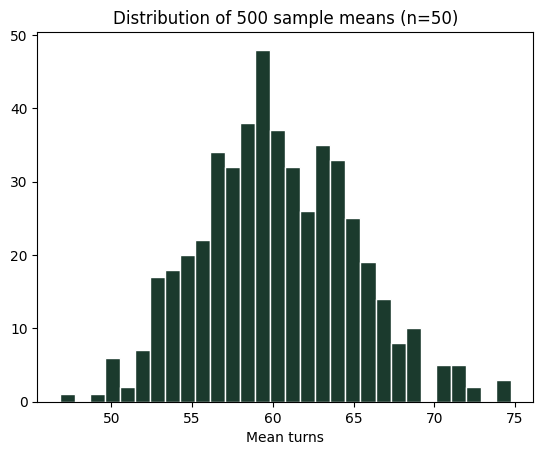

In [54]:
import matplotlib.pyplot as plot
sample_means = [
chess['turns'].sample(50, random_state=i).mean()
for i in range(500)
]
plot.hist(sample_means, bins=30, color='#1B3A2D', edgecolor='white')
plot.title('Distribution of 500 sample means (n=50)')
plot.xlabel('Mean turns') # → looks approximately normal!

Text(125.0, 700, 'Median')

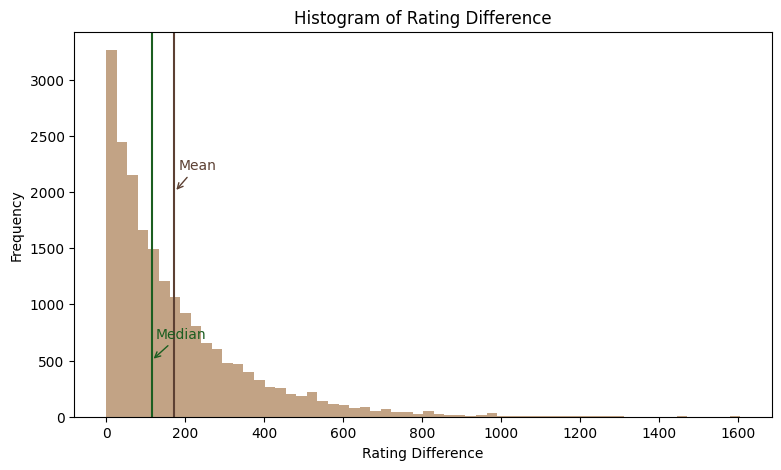

In [77]:
fig , ax = plot.subplots(figsize=(9,5))
image = plot.hist(chess['rating_diff'] , bins=60 , color='#C2A385')
image = plot.axvline(mean ,color = '#5C4033' , label = 'mean')
image = plot.axvline(median , color = '#1B5E20' , label = 'median')
ax.set_xlabel("Rating Difference")   
ax.set_ylabel("Frequency")           
ax.set_title("Histogram of Rating Difference")
ax.annotate('Mean',
            xy=(mean, 2000),          
            xytext=(mean+10, 2200),   
            arrowprops=dict(color='#5C4033', arrowstyle='->'),
            color='#5C4033')


ax.annotate('Median',
            xy=(median, 500),
            xytext=(median+10, 700),
            arrowprops=dict(color='#1B5E20', arrowstyle='->'),
            color='#1B5E20')

Text(0.5, 0, 'Mean rating diff')

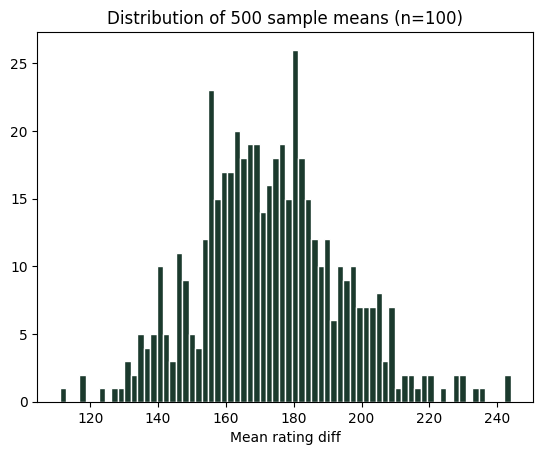

In [87]:
sample_means = [
chess['rating_diff'].sample(70, random_state=i).mean()
for i in range(500)
]
plot.hist(sample_means, bins=70, color='#1B3A2D', edgecolor='white')
plot.title('Distribution of 500 sample means (n=100)')
plot.xlabel('Mean rating diff')

Text(125.0, 700, 'Median')

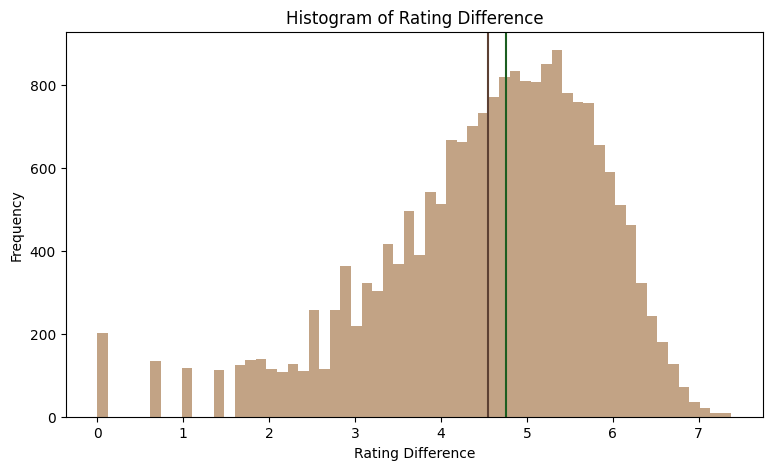

In [92]:
fig , ax = plot.subplots(figsize=(9,5))
image = plot.hist(np.log1p(chess['rating_diff']) , bins=60 , color='#C2A385')
image = plot.axvline(np.log1p(chess['rating_diff']).mean() ,color = '#5C4033' , label = 'mean')
image = plot.axvline(np.log1p(chess['rating_diff']).median() , color = '#1B5E20' , label = 'median')
ax.set_xlabel("Rating Difference")   
ax.set_ylabel("Frequency")           
ax.set_title("Histogram of Rating Difference")
ax.annotate('Mean',
            xy=(mean, 2000),          
            xytext=(mean+10, 2200),   
            arrowprops=dict(color='#5C4033', arrowstyle='->'),
            color='#5C4033')


ax.annotate('Median',
            xy=(median, 500),
            xytext=(median+10, 700),
            arrowprops=dict(color='#1B5E20', arrowstyle='->'),
            color='#1B5E20')

Text(125.0, 700, 'Median')

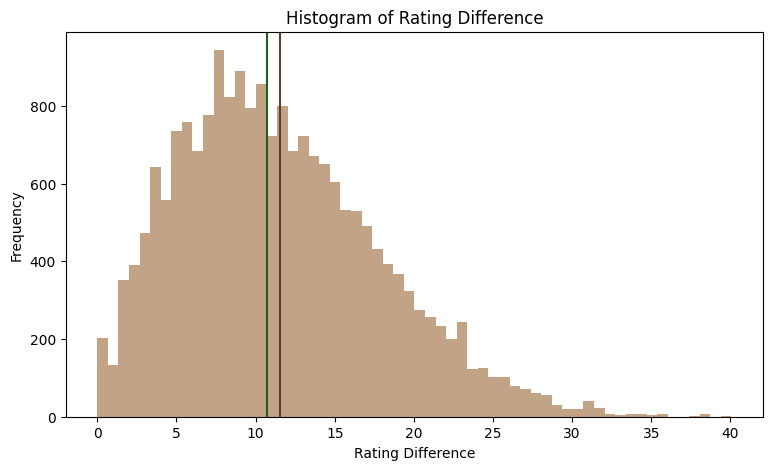

In [89]:
fig , ax = plot.subplots(figsize=(9,5))
image = plot.hist(np.sqrt(chess['rating_diff']) , bins=60 , color='#C2A385')
image = plot.axvline(np.sqrt(chess['rating_diff']).mean() ,color = '#5C4033' , label = 'mean')
image = plot.axvline(np.sqrt(chess['rating_diff']).median() , color = '#1B5E20' , label = 'median')
ax.set_xlabel("Rating Difference")   
ax.set_ylabel("Frequency")           
ax.set_title("Histogram of Rating Difference")
ax.annotate('Mean',
            xy=(mean, 2000),          
            xytext=(mean+10, 2200),   
            arrowprops=dict(color='#5C4033', arrowstyle='->'),
            color='#5C4033')


ax.annotate('Median',
            xy=(median, 500),
            xytext=(median+10, 700),
            arrowprops=dict(color='#1B5E20', arrowstyle='->'),
            color='#1B5E20')

In [ ]:
from sklearn.model_selection import train_test_split as tr 
train, test = tr(chess, test_size=0.2, random_state=42)
print(f"Full rated ratio: {chess['rated'].mean():.3f}") # 0.807
print(f"Train rated ratio: {train['rated'].mean():.3f}") # ~0.807 (close)
print(f"Test rated ratio: {test['rated'].mean():.3f}") # may drift slightly
# Stratified split — guarantees ratio preserved
train_s, test_s = tr(
chess, test_size=0.2,
stratify=chess['rated'],
random_state=42
)
print(f"Stratified test rated ratio: {test_s['rated'].mean():.3f}")

Full rated ratio: 0.805
Train rated ratio: 0.807
Test rated ratio: 0.799
Stratified test rated ratio: 0.805
